<a href="https://colab.research.google.com/github/joyshinola-byte/covid-19-python-project/blob/main/Covid_19_data_set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/covid_19_clean_complete.csv')
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [ ]:
df = df[['Date', 'Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active']]
df.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active
0,2020-01-22,Afghanistan,0,0,0,0
1,2020-01-22,Albania,0,0,0,0
2,2020-01-22,Algeria,0,0,0,0
3,2020-01-22,Andorra,0,0,0,0
4,2020-01-22,Angola,0,0,0,0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
print(df.isnull().sum())
df = df.drop_duplicates()

Date              0
Country/Region    0
Confirmed         0
Deaths            0
Recovered         0
Active            0
dtype: int64


In [ ]:
print("Total Confirmed:", df['Confirmed'].sum())
print("Total Deaths:", df['Deaths'].sum())
print("Total Recovered:", df['Recovered'].sum())

Total Confirmed: 828507763
Total Deaths: 43384902
Total Recovered: 388408160


**Line Chart**

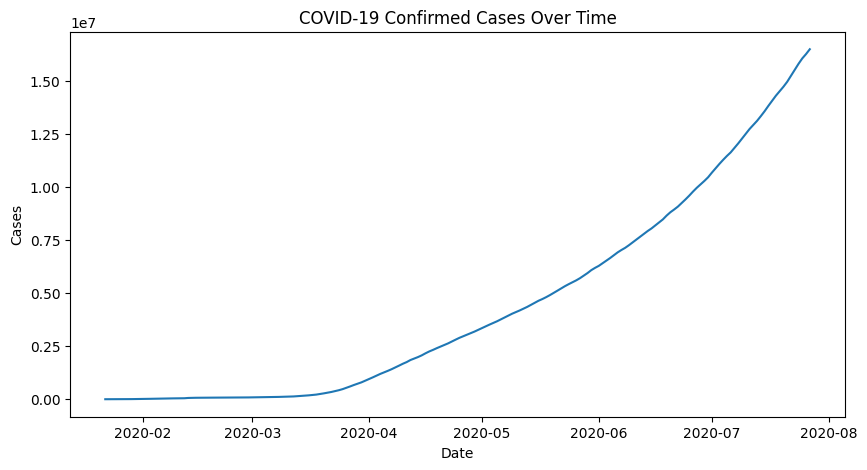

In [ ]:
daily = df.groupby('Date').sum(numeric_only=True)

plt.figure(figsize=(10,5))
plt.plot(daily.index, daily['Confirmed'])
plt.title("COVID-19 Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

**Bar Chart**

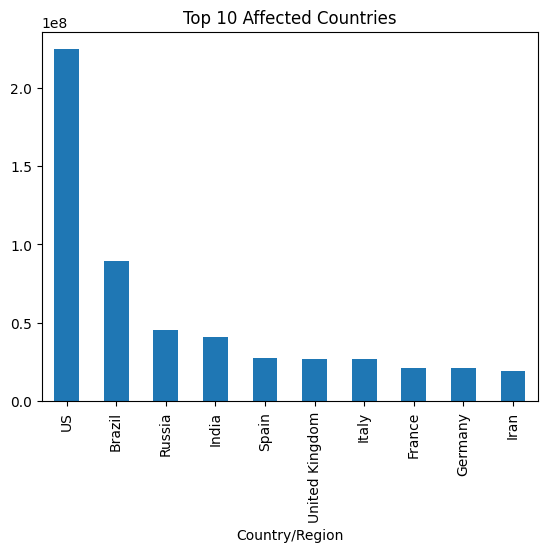

In [ ]:
country = df.groupby('Country/Region').sum(numeric_only=True)

top10 = country.sort_values(by='Confirmed', ascending=False).head(10)

top10['Confirmed'].plot(kind='bar')
plt.title("Top 10 Affected Countries")
plt.show()

**Pie Chart**

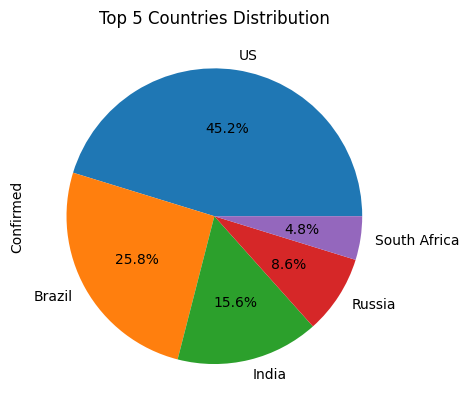

In [ ]:
latest = df[df['Date'] == df['Date'].max()]

data = latest.groupby('Country/Region').sum(numeric_only=True)

top5 = data.sort_values(by='Confirmed', ascending=False).head(5)

top5['Confirmed'].plot(kind='pie', autopct='%1.1f%%')
plt.title("Top 5 Countries Distribution")
plt.show()

**Scatter Plot**

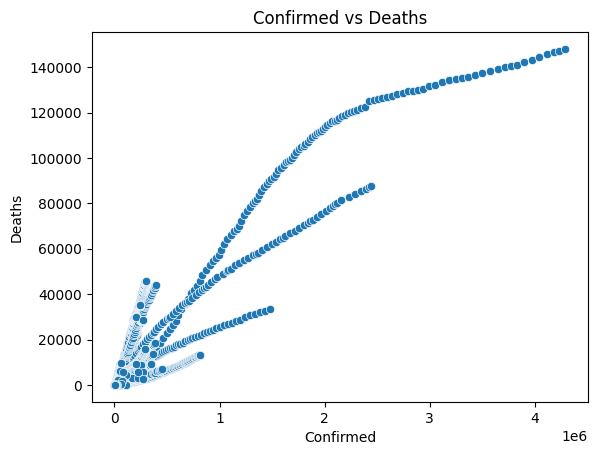

In [ ]:
sns.scatterplot(x=df['Confirmed'], y=df['Deaths'])
plt.title("Confirmed vs Deaths")
plt.show()

**Heat Map**

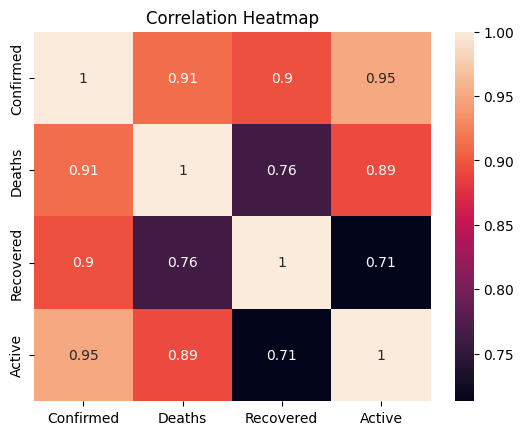

In [ ]:
corr = df[['Confirmed','Deaths','Recovered','Active']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

**Plotly Interactive Chart**

In [ ]:
fig = px.line(df, x='Date', y='Confirmed', color='Country/Region',
              title='COVID Trend by Country')

fig.show()